In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../datasets/student_performance_cleaned.csv")

### Relationship Analysis

In Machine Learning, it is not enough to understand each feature individually. We also need to understand how features are related to the target variable.

Relationship Analysis helps us identify which features may be useful for making predictions and which features have little or no relationship with the target variable.

In this notebook, the target variable is **Marks**. Therefore, we will analyze how different features relate to student marks.

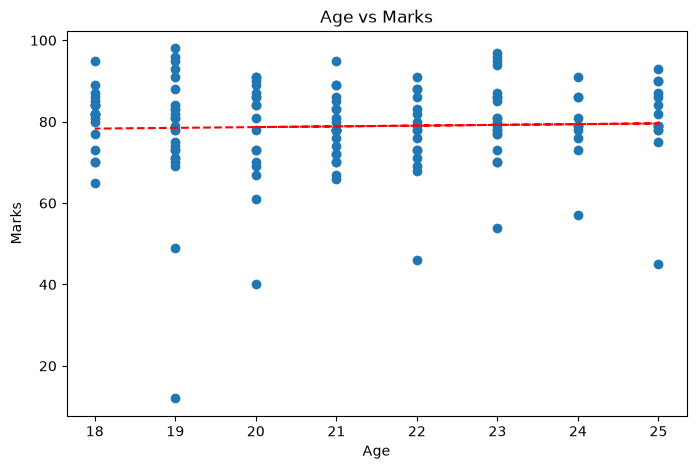

In [4]:
# Age Vs Marks
# Display the relationship between Age and Marks
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["marks"])

# Add this after plt.scatter
z = np.polyfit(df["age"], df["marks"], 1)  # linear fit
p = np.poly1d(z)
plt.plot(df["age"], p(df["age"]), color="red", linestyle="--")

plt.title("Age vs Marks")
plt.xlabel("Age")
plt.ylabel("Marks")

plt.show()

#### What to Observe

- Do marks increase as age increases?
- Is there any visible pattern?
- Are the points randomly scattered?

#### Why It Matters

- Helps determine whether Age is useful for predicting Marks.
- A clear pattern suggests that Age may be an important feature.
- A random pattern suggests little or no relationship.

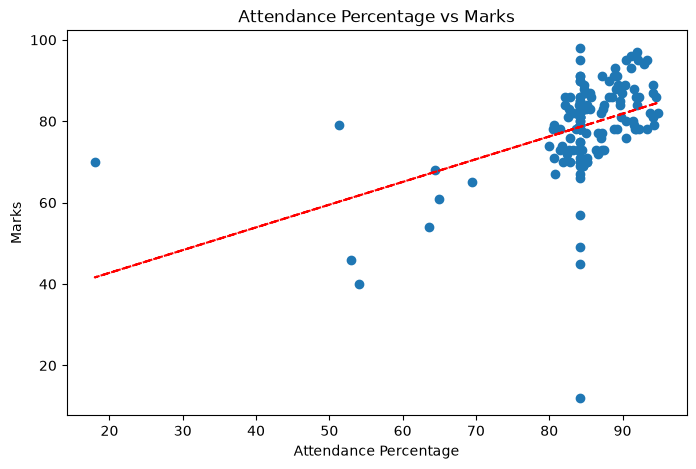

In [8]:
# Display the relationship between Attendance Percentage and Marks
plt.figure(figsize=(8,5))
plt.scatter(df["attendance_percentage"], df["marks"])

# Trendline
z = np.polyfit(df["attendance_percentage"], df["marks"], 1)
p = np.poly1d(z)
plt.plot(df["attendance_percentage"], p(df["attendance_percentage"]), color="red", linestyle="--")

plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")

plt.show()

#### What to Observe

- Do students with higher attendance generally achieve higher marks?
- Is there a positive trend?
- Are there any unusual observations?

#### Why It Matters

- Helps determine whether Attendance Percentage is a useful feature.
- A positive relationship may improve the predictive performance of a Machine Learning model.

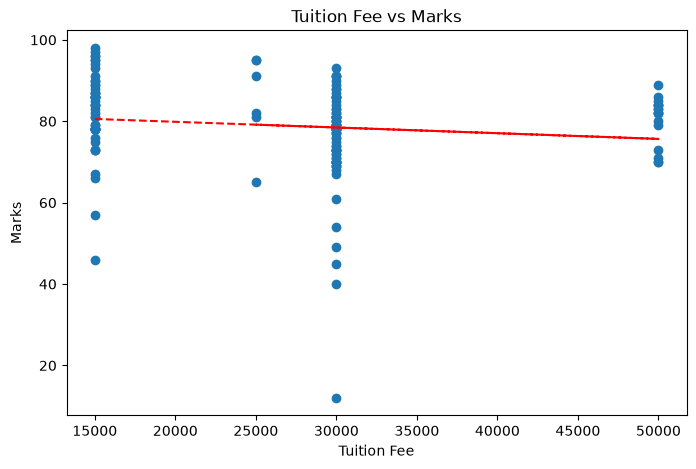

In [9]:
# Display the relationship between Tuition Fee and Marks
plt.figure(figsize=(8,5))
plt.scatter(df["tuition_fee"], df["marks"])

# Trendline
z = np.polyfit(df["tuition_fee"], df["marks"], 1)
p = np.poly1d(z)
plt.plot(df["tuition_fee"], p(df["tuition_fee"]), color="red", linestyle="--")

plt.title("Tuition Fee vs Marks")
plt.xlabel("Tuition Fee")
plt.ylabel("Marks")

plt.show()

#### What to Observe

- Does paying a higher tuition fee relate to higher marks?
- Is there any visible relationship?
- Are the points randomly distributed?

#### Why It Matters

- Helps determine whether Tuition Fee contributes useful information for predicting Marks.

### **Understanding Relationships**

A relationship between two variables can be:

##### *Strong Positive Relationship*

- As one variable increases, the other also increases.
- Example: Attendance ↑ → Marks ↑

##### *Strong Negative Relationship*

- As one variable increases, the other decreases.
- Example: Study Time ↑ → Errors ↓

##### *Weak Relationship*

- A slight relationship exists, but it is not very strong.

##### *No Relationship*

- One variable does not appear to affect the other.
- The points are randomly scattered.

| Scatter Plot Pattern | Interpretation          | Useful for ML?        |
| -------------------- | ----------------------- | --------------------- |
| 📈 Upward Trend      | Positive Relationship   | ✅ Usually Yes         |
| 📉 Downward Trend    | Negative Relationship   | ✅ Usually Yes         |
| ☁ Random Scatter     | No Relationship         | ❌ Usually No          |
| 🔵 Clustered Groups  | Possible Hidden Pattern | ⚠ Investigate Further |


#### Correlation Analysis

Correlation measures the strength and direction of the relationship between two numerical variables.

It helps us understand whether a feature is useful for predicting the target variable.

#### Correlation Range

The Pearson correlation coefficient ranges from **-1 to +1**.

- **+1** → Perfect Positive Relationship
- **0** → No Relationship
- **-1** → Perfect Negative Relationship

#### Interpreting Correlation Values

| Correlation (r) | Interpretation |
|----------------:|----------------|
| **0.70 to 1.00** | Strong Positive Relationship |
| **0.30 to 0.69** | Moderate Positive Relationship |
| **-0.29 to 0.29** | Weak or No Relationship |
| **-0.69 to -0.30** | Moderate Negative Relationship |
| **-1.00 to -0.70** | Strong Negative Relationship |

Correlation is widely used in Feature Selection before training Machine Learning models.

In [13]:
# Calculate the correlation matrix
df.corr(numeric_only=True)

,student_id,age,semester,marks,attendance_percentage,tuition_fee
student_id,1.000000,-0.124081,-0.104839,0.023844,0.077633,-0.062125
age,-0.124081,1.000000,0.915036,0.035040,0.007863,-0.313833
semester,-0.104839,0.915036,1.000000,0.026870,0.024183,-0.394283
marks,0.023844,0.035040,0.026870,1.000000,0.431874,-0.131767
attendance_percentage,0.077633,0.007863,0.024183,0.431874,1.000000,-0.158591
tuition_fee,-0.062125,-0.313833,-0.394283,-0.131767,-0.158591,1.000000


##### What to Observe

- Which features have the highest correlation with Marks?
- Which features have very little correlation?
- Are any two features highly correlated with each other?

##### Why It Matters

- Features with stronger relationships to the target variable are often more useful for prediction.
- Highly correlated features may contain similar information.
- Correlation helps us perform Feature Selection before model training.

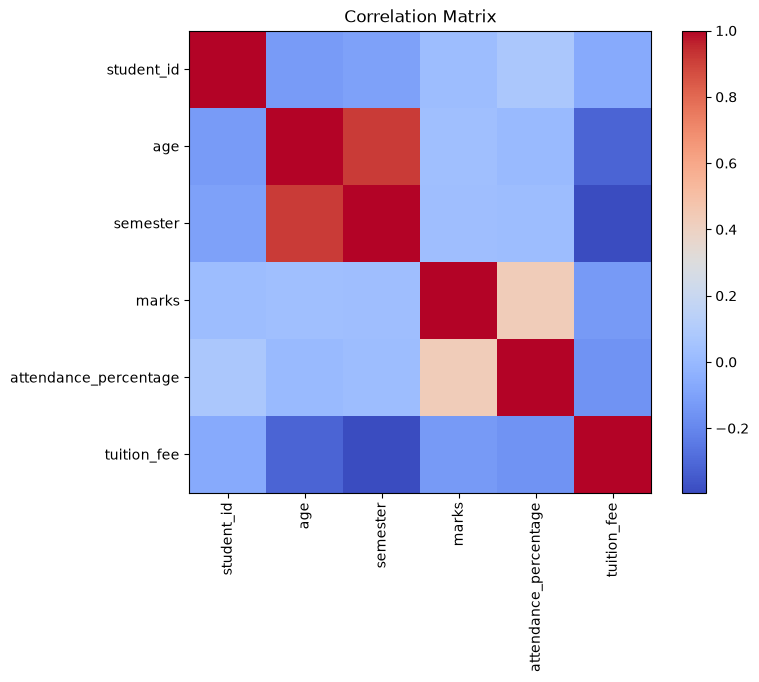

In [14]:
# Display the correlation matrix
plt.figure(figsize=(8,6))

plt.imshow(df.corr(numeric_only=True), cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns,
    rotation=90
)

plt.yticks(
    range(len(df.corr(numeric_only=True).columns)),
    df.corr(numeric_only=True).columns
)

plt.title("Correlation Matrix")

plt.show()

##### What to Observe

- Which cells have the darkest red color?
- Which cells have the darkest blue color?
- Which features have colors close to white?

##### Why It Matters

- Dark Red → Strong Positive Relationship
- Dark Blue → Strong Negative Relationship
- White → Little or No Relationship

This helps identify useful features before training a Machine Learning model.

In [15]:
# Display the correlation of all numerical features with Marks
df.corr(numeric_only=True)["marks"].sort_values(ascending=False)

marks                    1.000000
attendance_percentage    0.431874
age                      0.035040
semester                 0.026870
student_id               0.023844
tuition_fee             -0.131767
Name: marks, dtype: float64

##### What to Observe

- Which feature has the highest positive correlation with Marks?
- Which feature has the lowest correlation with Marks?
- Which features may contribute little to prediction?

##### Why It Matters

- Features with stronger correlations are often better candidates for Machine Learning models.
- Features with very weak correlations may contribute less useful information.

In [17]:
# Display features with a correlation greater than 0.30
corr = df.corr(numeric_only=True)["marks"]

corr[corr.abs() > 0.30]

marks                    1.000000
attendance_percentage    0.431874
Name: marks, dtype: float64

##### What to Observe

- Which features have relatively strong relationships with Marks?
- Which features may be considered for model training?

##### Why It Matters

- Strongly related features often provide more predictive information.
- This is an initial step in Feature Selection.

> **Important**

Correlation does not prove that one variable causes another.

It only measures how strongly two variables move together.

A high correlation suggests that two variables are related, but additional analysis is required to determine whether one variable actually influences the other.